In [120]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.distributions.uniform import Uniform #初始化NN的隨機值weightings
from torch.utils.data import TensorDataset, DataLoader#用很多training data，創造大型scale Embedding Network

import lightning as L#減少code，在雲端自動最佳化與scale

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
inputs = torch.tensor([[1, 0, 0, 0],
                      [0, 1, 0, 0],
                       [0, 0, 1, 0],
                       [0, 0, 0, 1]])
#我們的目標是: 創造一個簡單的神經網絡，可以預測一個特定的input的token，
#比如:input token是Troll2，預測是is，也就是is = 1，其他token的output是0
#在Pytorch，這代表我們想預測is的one-hot encoding: [0, 1, 0, 0] 

#同理:input token是is，預測是great，這代表我們想預測great的one-hot encoding: [0, 0, 1, 0] 

#理論上，在great之後不該再預測其他東西，但是如果taining data很大，可能會跑出一些東西，
#像是這裡，就要避免預測出:Gymkata，然後又預測出is...，所以Gymkata和Troll2一樣，預測要是is


In [122]:
# labels = torch.tensor([[0, 1, 0, 0],
#                       [0, 0, 1, 0],
#                        [0, 0, 0, 1],
#                        [0, 1, 0, 0]])

#nn.CrossEntropyLoss 需要的是類別的索引值（如 1、2 等），而不是 one-hot 向量。
labels = torch.tensor([1, 2, 3, 1]) 

#用這些dataset創造一個DataLoader，稱為dataloader
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

#現在資料處理好了，接下要寫些code，處理Word Embedding network

In [123]:
#使用Pytroch，一開始要定義新的class
class WordEmbeddingFromScratch(L.LightningModule):

    #創造initialization method給新的class
    def __init__(self):
        #創造與初始化Embedding Network的weighting tensors，也創造一個訓練期間的loss function
        super().__init__() #呼叫初始化方法給母體類別，LightningModule；在Python不論何時我們從一 個class繼承都需要，在這裡，這將讓我們利用Lightning的所有特徵
        
        #這裡出初始化隨機值用Uiniform(-0.5,0.5)，且每個值被挑到的機率一樣
        #會用-0.5~0.5，是為了搭配第二部分的Pytorch Linear()的計算，Linear()選擇數值的範圍是基於inputs的數量
        min_value = -0.5
        max_value = 0.5

        #加入第一個input的第一個weightings，使用Uniform().sample()用一個隨機值初始化它
        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        #創造與初始化所有和inputs有關的參數weightings
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        
        #同理，創造與初始化所有和outputs有關的參數weightings
        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        #最後，在__init__，讓class接收cross entropy 
        self.loss = nn.CrossEntropyLoss()#呼叫nn.CrossEntropyLoss()，儲存在變數:loss
        
        
    def forward(self, input):
        #做一個向前的通道，通過Embedding Network，對於forward() method，input是一個list，由每一個input token的one-hot coding組成
        #例如: [1, 0, 0, 0]可能是Troll2的one-hot encoding，但通過forward()，它會被包在一個括號裡面，[[1, 0, 0, 0]]
        #所以要先設置input的那些元素，移除那些括號
        input = input[0]

        #然後乘上weighting、加入激活函數，儲存這個sum，這變數命名為inpiuts_to_top_hidden
        inputs_to_top_hidden = ((input[0] * self.input1_w1) + 
                                 (input[1] * self.input2_w1) +
                                 (input[2] * self.input3_w1) + 
                                 (input[3] * self.input4_w1))
        #另外一個是inpuuts_to_bottom_hidden
        inputs_to_bottom_hidden = ((input[0] * self.input1_w2) + 
                                    (input[1] * self.input2_w2) +
                                    (input[2] * self.input3_w2) + 
                                    (input[3] * self.input4_w2))
        #以上就是第一部分的Word Embedding network
        #因為激活函數是恆等函數，所以inpuuts_to_top_hidden和inpuuts_to_bottom_hidden直接乘上下一部分的weightings
        output1 = ((inputs_to_top_hidden*self.output1_w1) +
                   (inputs_to_bottom_hidden*self.output1_w2))
        output2 = ((inputs_to_top_hidden*self.output2_w1) +
                   (inputs_to_bottom_hidden*self.output2_w2))
        output3 = ((inputs_to_top_hidden*self.output3_w1) +
                   (inputs_to_bottom_hidden*self.output3_w2))
        output4 = ((inputs_to_top_hidden*self.output4_w1) +
                   (inputs_to_bottom_hidden*self.output4_w2))

        #計算完後通過SoftMax，但在backpropagation正用在loss上，nn.CrossEntropyLoss()已經為我們做SoftMax
        #所以做後我們只要用torch.stack包裝output的值，儲存在變數output_presoftmax
        output_presoftmax = torch.stack([output1,output2, output3, output4])#沒有用torch.stack會只回傳output values的list，沒有梯度也不能做backpropagation
        return (output_presoftmax) #最後forward() method回傳output_presoftmax
        
        
    def configure_optimizers(self):
        #創造一個method，執行Adam optimizer
        return Adam(self.parameters(), lr=0.1)#因為這個例子簡單，我們希望執行快意點，所以用相對大的lr

    def training_step(self, batch, batch_idx):
        #最後創造一個method: training_step，計算loss，這裡我們用cross entropy loss
        input_i, label_i = batch  #input_i: split batch of training data into input,[1,0,0,0]、[0,1,0,0]...;label_i: ideal output values
        output_i = self.forward(input_i) #將input傳遞給 forward() 方法，通過該方法將數據傳遞到網路中，直到達到 SoftMax() 函數為止，
                                        #例如: 執行Troll2的one-hot encoding，通過沒訓練的網絡，那麼forward()的值將會return
        loss = self.loss(output_i, label_i[0])#通過loss function，nn.CrossEntropyLoss()將會讓output values通過SoftMax，比較SoftMax的output與理想值的差異，儲存在變數loss
        return loss

In [124]:
#用剛剛寫的class: WordEmbeddingFromScratch，創造新的Word Embedding，命名為modelFromScratch
modelFromScratch = WordEmbeddingFromScratch()

#先用隨機選擇的weightings預測
print("Before optimizing, the parameters are...")
for name, param in modelFromScratch.named_parameters(): #這loop會迭代所有在神經網絡裡的named parameters
    print(name, param.data)#印出每個參數的名字與數值

Before optimizing, the parameters are...
input1_w1 tensor(-0.0475)
input1_w2 tensor(-0.2421)
input2_w1 tensor(-0.2497)
input2_w2 tensor(-0.3702)
input3_w1 tensor(-0.3449)
input3_w2 tensor(-0.2449)
input4_w1 tensor(-0.3546)
input4_w2 tensor(-0.2123)
output1_w1 tensor(-0.3436)
output1_w2 tensor(0.0575)
output2_w1 tensor(-0.0175)
output2_w2 tensor(-0.0086)
output3_w1 tensor(0.0180)
output3_w2 tensor(-0.4848)
output4_w1 tensor(0.4352)
output4_w2 tensor(0.3401)


In [125]:
# 這些數字的清單有些難閱讀，我們可以把它做成DataFrame，可以先把wightings數值放入字典

data = { #儲存這字典在變數data
    "w1": [modelFromScratch.input1_w1.item(),#Part1: labeled w1，包含每個input的weighting，前往頂端的激活函數；.item()是要得到weighting，因為它會回傳tensor values為python number
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),#Part2: labeled w2，包含每個input的weighting，前往下端的激活函數；
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    # "Token": ["Troll2","is","great","Gymkata"],#label tokens and inputs
    "Token": ["Godzilla","is","cool","King Ghidorah"],
    "input": ["input1","input2","input3","input4"]
          
}

df = pd.DataFrame(data) #轉換data為Pandas Dataframe
df #我們可以看出，Troll2的weightings(w1和w2)和Gymkata的weightings(w1和w2)有很大的不同，即使他們的movie title都被用於一樣的上下文

,w1,w2,Token,input
0,-0.047490,-0.242105,Godzilla,input1
1,-0.249663,-0.370218,is,input2
2,-0.344915,-0.244900,cool,input3
3,-0.354624,-0.212264,King Ghidorah,input4


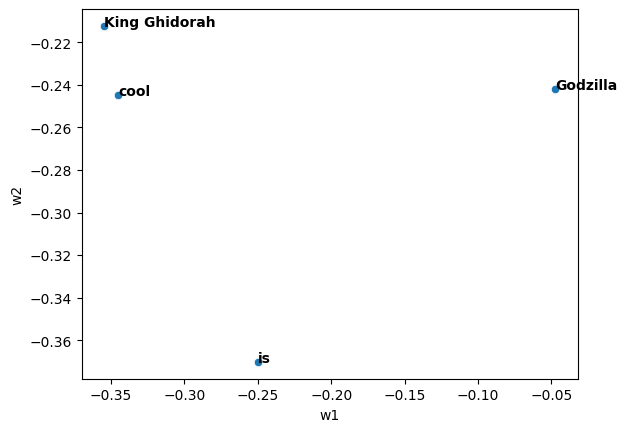

In [126]:
#畫成散佈圖:上方的激活函數在x軸，下方的激活函數w2在y軸...
#這圖就容易看Troll2的Embedding values和Gymkata非常不同
sns.scatterplot(data=df, x='w1', y='w2')

#用matplotlib的text()，加入Tokens為labels到每個點
plt.text(df.w1[0], df.w2[0], df.Token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[1], df.w2[1], df.Token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[2], df.w2[2], df.Token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[3], df.w2[3], df.Token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [127]:
# Troll2的Embedding values和Gymkata非常不同，所以我們要去訓練Embedding network

trainer = L.Trainer(max_epochs = 100)#創造一個Lightning.Trainer，命名為trainer，最多鉉練100 epochs
#意思是: 對每一個weightings，使用這個training data，最多做100次的backpropagtion
#training data: Troll2 is great、Gymkata is great

trainer.fit(modelFromScratch, train_dataloaders=dataloader)
#呼叫fit()，通過稱為modelFromScratch的Embedding network與被稱為dataloader的training data

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | CrossEntropyLoss | 0      | train
  | other params | n/a              | 16     | n/a  
----------------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
C:\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Python310\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (4) is smaller than the

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.


In [128]:
for batch in dataloader:
    print(batch)

[tensor([[1, 0, 0, 0]]), tensor([1])]
[tensor([[0, 1, 0, 0]]), tensor([2])]
[tensor([[0, 0, 1, 0]]), tensor([3])]
[tensor([[0, 0, 0, 1]]), tensor([1])]


In [129]:
#執行完後，重新創造一個dataframe，有每個token的weightings、Embedding valuues

data = { #儲存這字典在變數data
    "w1": [modelFromScratch.input1_w1.item(),#Part1: labeled w1，包含每個input的weighting，前往頂端的激活函數；.item()是要得到weighting，因為它會回傳tensor values為python number
           modelFromScratch.input2_w1.item(),
           modelFromScratch.input3_w1.item(),
           modelFromScratch.input4_w1.item()],
    "w2": [modelFromScratch.input1_w2.item(),#Part2: labeled w2，包含每個input的weighting，前往下端的激活函數；
           modelFromScratch.input2_w2.item(),
           modelFromScratch.input3_w2.item(),
           modelFromScratch.input4_w2.item()],
    "Token": ["Godzilla","is","cool","King Ghidorah"],#label tokens and inputs
    "input": ["input1","input2","input3","input4"]
          
}

df = pd.DataFrame(data) #轉換data為Pandas Dataframe
df #我們可以看出，Troll2的weightings(w1和w2)和Gymkata的weightings(w1和w2)有很大的不同，即使他們的movie title都被用於一樣的上下文

,w1,w2,Token,input
0,-2.249660,-1.338560,Godzilla,input1
1,1.806765,-2.235409,is,input2
2,1.342374,2.082008,cool,input3
3,-2.279231,-1.477922,King Ghidorah,input4


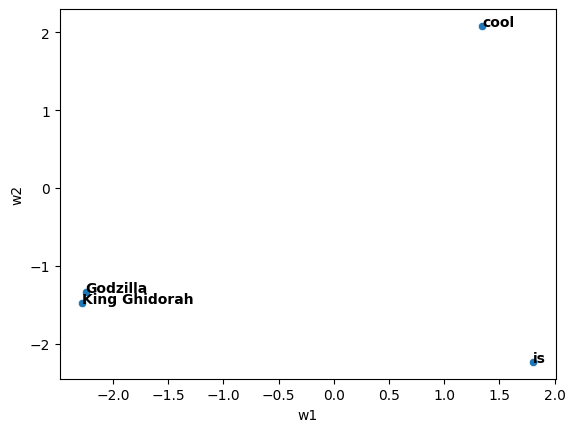

In [130]:
#再次劃出tokens的散佈圖
#這圖就容易看Troll2的Embedding values和Gymkata非常接近
sns.scatterplot(data=df, x='w1', y='w2')

#用matplotlib的text()，加入Tokens為labels到每個點
plt.text(df.w1[0], df.w2[0], df.Token[0],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[1], df.w2[1], df.Token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[2], df.w2[2], df.Token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[3], df.w2[3], df.Token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

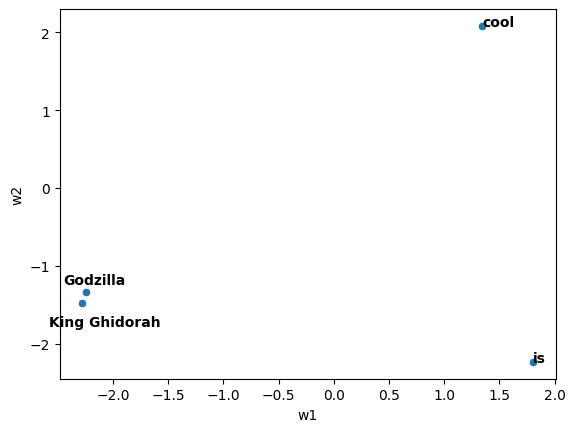

In [131]:
#如果Troll2和Gymkata非常重疊，我們可以給Troll2一點點offsets
#再次劃出tokens的散佈圖
#這圖就容易看Troll2的Embedding values和Gymkata非常接近
sns.scatterplot(data=df, x='w1', y='w2')

#用matplotlib的text()，加入Tokens為labels到每個點
plt.text(df.w1[0] -0.2, df.w2[0] +0.1, df.Token[0], # offsets for Troll2
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[1], df.w2[1], df.Token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[2], df.w2[2], df.Token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[3] -0.3, df.w2[3] -0.3, df.Token[3], # offsets for Gymkata
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [94]:
#當我們input Troll2，預測出is，首先要建立SoftMax()函數，因為到現在為止，我們並沒有直接使用它
softmax = nn.Softmax(dim = 0) # dim = 0表示我們要使用的是output values的rows、1就是output values的cols

#讓Troll2的one-hot encoded tensor通過modelFromScratch
print(torch.round(softmax(modelFromScratch(torch.tensor([[1., 0., 0., 0.]]))),decimals=2))


tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)


In [95]:
#同樣的，可以再把其他inputs放到Embedding network，創造正確的outputs
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 1., 0., 0.]]))),decimals=2))
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 1., 0.]]))),decimals=2))
print(torch.round(softmax(modelFromScratch(torch.tensor([[0., 0., 0., 1.]]))),decimals=2))

tensor([0., 0., 1., 0.], grad_fn=<RoundBackward1>)
tensor([0., 0., 0., 1.], grad_fn=<RoundBackward1>)
tensor([0., 1., 0., 0.], grad_fn=<RoundBackward1>)


In [96]:
#創造新的class，命名為WordEmbeddingWithLinear，為了簡單訓練，繼承LightningMudule
class WordEmbeddingWithLinear(L.LightningModule):
    # __init__() method用來創造與初始化weightings
    def __init__(self):

        super().__init__()#呼叫母體類別
        #這裡不用再呼叫nn.Parameter()創造與初始化network的weightings，只要呼叫nn.Linear()
        self.input_to_hidden = nn.Linear(in_features=4, out_features=2, bias=False)#第一個call是創造inputs與hidden layer之間的weightings
          #in_features=4: 表示連結4個inputs, out_features=2:在hidden layer有2個nodes；這表示: 這個對nn.Linear的call，有4個weightings，且這個hidden layer有2個nodes
          #因為不用bias，所以設置為False
        self.hidden_to_output = nn.Linear(in_features=2, out_features=4, bias=False)#第二個call是創造hidden layer與outputs之間的weightings
          #in_features=2, out_features=4 : 2個weightings，連接到4個outputs

        #最後給class接受Cross Entropy loss function
        self.loss = nn.CrossEntropyLoss()

    def forward(self, input):#製作forward pass通過network，在抵達激活函數前，要先計算sum

        input = input.float() #最後用Linear()最佳化，.fit要轉為float
        
        hidden = self.input_to_hidden(input) #在___init__()input通過Linear object，input_to_hidden，儲存這些sum在變數hidden
           #這個Linear object: input_to_hidden，會幫我們做乘法與加法，使用Linear就不用再分開input: [[1,0,0,0]]的額外括號
           #因為我們放置激活函數是在output，我們可以忽略它
        
        output_values = self.hidden_to_output(hidden)#通過hidden到我們創造的第二個Linear object，hidden_to_output
           #hidden_to_output會計算來自激活函數的output sums，儲存在變數output_values
        #Note: 不用去計算SoftMax，因為nn.CrossEntropyLoss()會幫我們算

        return (output_values)

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.1) #用Adam optimizer將參數最佳化，學習率=0.1

    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = self.loss(output_i, label_i)

        return loss
#使用nn.Linear(),class的定義，code量也減少很多，先前進行scale倒是比較能詳細觀察

In [97]:
modelLinear = WordEmbeddingWithLinear() #用WordEmbeddingWithLinear創造新模型modelLinear

#像之前一樣，訓練前的Embedding values放入DataFrame，為df
data = {
    "w1":modelLinear.input_to_hidden.weight.detach()[0].numpy(),
         #input_to_hidden.weight是nn.Linear創造的weightings，我們用.weight得到它；.detach()是移除tensors的梯度
    "w2":modelLinear.input_to_hidden.weight.detach()[1].numpy(),
         #[0]和[1]是取上下兩個激活函數前面的weightings；.numpy()是把tensor轉為numpy array
    "Token":["Godzilla","is","cool","King Ghidorah"],
    "input":["input1","input2","input3","input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,Token,input
0,0.001412,0.101598,Godzilla,input1
1,0.033126,0.148224,is,input2
2,0.463500,-0.484790,cool,input3
3,0.017932,-0.033810,King Ghidorah,input4


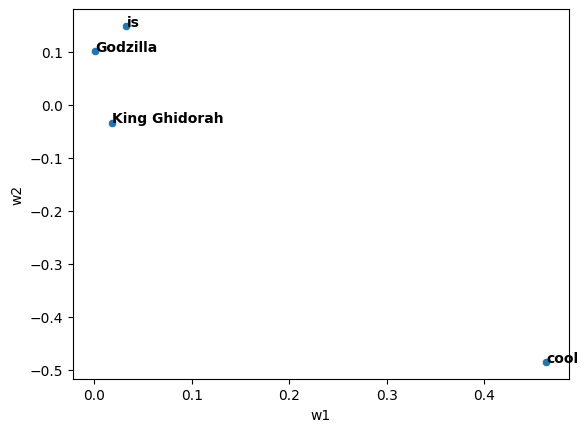

In [98]:
#畫Tokens的散佈圖
sns.scatterplot(data=df, x='w1', y='w2')

#用matplotlib的text()，加入Tokens為labels到每個點
plt.text(df.w1[0], df.w2[0], df.Token[0], 
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[1], df.w2[1], df.Token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[2], df.w2[2], df.Token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[3], df.w2[3], df.Token[3],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [99]:
trainer = L.Trainer(max_epochs = 100)#訓練模型100epochs
trainer.fit(modelLinear,train_dataloaders=dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | input_to_hidden  | Linear           | 8      | train
1 | hidden_to_output | Linear           | 8      | train
2 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
C:\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Python310\lib\site-packages\lightning\pytorch\

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.


In [100]:
#訓練後，input到hidden layer的weightings與到最後的weightings產生新的Embedding values

In [101]:
modelLinear = WordEmbeddingWithLinear() #用WordEmbeddingWithLinear創造新模型modelLinear

#像之前一樣，訓練前的Embedding values放入DataFrame，為df
data = {
    "w1":modelLinear.input_to_hidden.weight.detach()[0].numpy(),
         #input_to_hidden.weight是nn.Linear創造的weightings，我們用.weight得到它；.detach()是移除tensors的梯度
    "w2":modelLinear.input_to_hidden.weight.detach()[1].numpy(),
         #[0]和[1]是取上下兩個激活函數前面的weightings；.numpy()是把tensor轉為numpy array
    "Token":["Godzilla","is","cool","King Ghidorah"],
    "input":["input1","input2","input3","input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,Token,input
0,0.035239,-0.358955,Godzilla,input1
1,0.435793,0.352659,is,input2
2,-0.493117,-0.365939,cool,input3
3,-0.261745,0.285649,King Ghidorah,input4


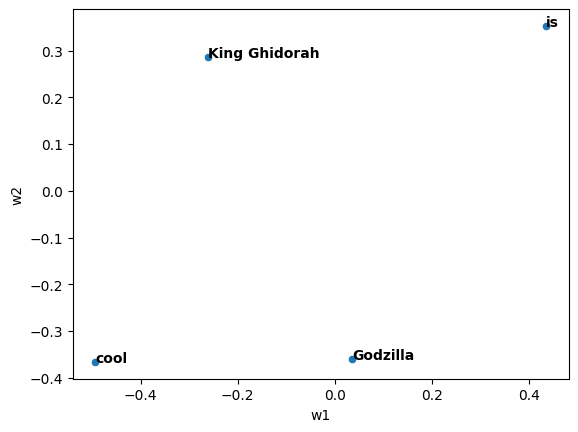

In [102]:

#再次劃出tokens的散佈圖
#這圖就容易看Troll2的Embedding values和Gymkata非常接近
sns.scatterplot(data=df, x='w1', y='w2')

#用matplotlib的text()，加入Tokens為labels到每個點
plt.text(df.w1[0], df.w2[0], df.Token[0], # offsets for Troll2
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[1], df.w2[1], df.Token[1],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[2], df.w2[2], df.Token[2],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')
plt.text(df.w1[3] , df.w2[3] , df.Token[3], # offsets for Gymkata
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold')

plt.show()

In [103]:
#得到這兩串的Embedding values，上一串是inputs給第一個激活函數的weightings，下一串是inputs給第二個激活函數的weightings
modelLinear.input_to_hidden.weight

Parameter containing:
tensor([[ 0.0352,  0.4358, -0.4931, -0.2617],
        [-0.3590,  0.3527, -0.3659,  0.2856]], requires_grad=True)

In [104]:
word_embedding = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T) #創造nn.Embedding object，用..from_pretrained()讓訓練前的weightings通過
  #用.T將weightings的rows轉為cols，最後，儲存新的Embedding object在word_embedding

In [105]:
word_embedding.weight #印出weightings

Parameter containing:
tensor([[ 0.0352, -0.3590],
        [ 0.4358,  0.3527],
        [-0.4931, -0.3659],
        [-0.2617,  0.2856]])

In [106]:
#印出第一個input: Troll2的Embedding values，藉由使tensor第一個index value: 0通過
word_embedding(torch.tensor(0)) #這就是Troll2到兩個激活函數的weightings

tensor([ 0.0352, -0.3590])

In [107]:
#用index得到Embedding values，但也可以用一個字典，把Tokens map到他們的indices
vocab = {
    "Godzilla": 0,
    "is": 1,
    "cool" :2,
    "King Ghidorah": 3
}

word_embedding(torch.tensor(vocab['Godzilla'])) #這樣就可以不用index，更容易獲得某個Token的embeddings

tensor([ 0.0352, -0.3590])

Decording-Only Transformer

In [1]:
import torch #創建tensors，儲存 raw data，以及一些有幫助的函數
import torch.nn as nn #使用Modual、Linear、Embedding classes以及一串有幫助的函數
import torch.nn.functional as F #接收softmax()，用來計算attention

from torch.optim import Adam #使用backpropagation你和神經網絡與資料
from torch.utils.data import TensorDataset, DataLoader#創造一個有很多training data的大型scale Transformer network

import lightning as L #自動最佳化與scaling，減少code

In [2]:
#因此，組成的單字就是以下的tokens...，再將這些tokens map到 id numbers，
#因為Pytorch的word Embedding函數: nn.Embedding()，只接受數字型的input
# token_to_id = {"what": 0,
#                "is": 1,
#                "statquest": 2,
#                "awesome": 3,
#                "<EOS>":4,
# }

token_to_id = {"what": 0,
               "is": 1,
               "apple": 2,
               "fruit": 3,
               "<EOS>":4,
}

#寫成字典，儲存在token_to_id

#這個id_to_token是另一個字典，將數字變回token
id_to_token = dict(map(reversed, token_to_id.items()))

#這些字典有助於形成input到Transormer，以及解釋從Transormer出來的output，
#皆下來我們要討論，如何將What is StatQuest？ 以及StatQuest is What？轉換成 Awesome! (也就是這兩個prompts如何反應到一個dataset)

In [3]:
# inputs = torch.tensor([[token_to_id["what"],
#                         token_to_id["is"],
#                         token_to_id["statquest"],
#                         token_to_id["<EOS>"],
#                         token_to_id["awesome"]],
                       
#                        #如果prompt是StatQuest is What，就用token_to_tensor code一個input tensor
#                        [token_to_id["statquest"],
#                         token_to_id["is"],
#                         token_to_id["what"],
#                         token_to_id["<EOS>"],
#                         token_to_id["awesome"]]])

inputs = torch.tensor([[token_to_id["what"],
                        token_to_id["is"],
                        token_to_id["apple"],
                        token_to_id["<EOS>"],
                        token_to_id["fruit"]],
                       
                       #如果prompt是StatQuest is What，就用token_to_tensor code一個input tensor
                       [token_to_id["apple"],
                        token_to_id["is"],
                        token_to_id["what"],
                        token_to_id["<EOS>"],
                        token_to_id["fruit"]]])

In [4]:
inputs

tensor([[0, 1, 2, 4, 3],
        [2, 1, 0, 4, 3]])

In [5]:
# labels = torch.tensor([[token_to_id["is"],
#                         token_to_id["statquest"],
#                         token_to_id["<EOS>"],
#                         token_to_id["awesome"],
#                         token_to_id["<EOS>"]],
                        
#                         #再code the label for the second prompt是...
#                         [token_to_id["is"],
#                         token_to_id["what"],
#                         token_to_id["<EOS>"],
#                         token_to_id["awesome"],
#                         token_to_id["<EOS>"]]])

# #以上就是第一個prompt和response的input與label

labels = torch.tensor([[token_to_id["is"],
                        token_to_id["apple"],
                        token_to_id["<EOS>"],
                        token_to_id["fruit"],
                        token_to_id["<EOS>"]],
                        
                        #再code the label for the second prompt是...
                        [token_to_id["is"],
                        token_to_id["what"],
                        token_to_id["<EOS>"],
                        token_to_id["fruit"],
                        token_to_id["<EOS>"]]])

#以上就是第一個prompt和response的input與label

In [6]:
labels

tensor([[1, 2, 4, 3, 4],
        [1, 0, 4, 3, 4]])

In [7]:
#將input和label送進TensorDataset()去創造dataset
dataset = TensorDataset(inputs, labels)

#將dataset送入DataLoader()建立dataloadr
dataloader = DataLoader(dataset)

In [113]:
#以下code是用於計算前，把Position Encoding values加到tokens
class PositionEncoding(nn.Module):#定義新的class，PositionEncoding，繼承nn.Module

    def __init__(self, d_model=2, max_len=6):#dim of model，就是每個token，word Embedding的數量；max_len是Transformer的tokens的最大數量(包含inputs和outputs)
                       #這裡設d_model=2, max_len=6，但一般不會這麼小
        super().__init__() #呼叫nn.Module的__init__ method
        
        pe = torch.zeros(max_len, d_model)#創造一個Position Encoding values的矩陣，起始都為0s，命名為pe(Position Encoding)
                                          #pe的row與max_len一樣大，且col與d_model一樣大
        
        position = torch.arange(start=0, end=max_len, step=1).float().unsqueeze(1)#position是一個column matrix，表示每個token的位置(pos)
                                                                                 #用torch.arang()創造數列，再0與max_len之間，確定值是float，.unsqueeze(1)是轉換數列成一個column matrix
        embedding_index = torch.arange(start=0, end=d_model, step=2).float()#embedding_index是一個row matrix，代表對於每個word embedding，index i，i都乘2，
                                                                            #所以d_model = 2，embedding_index就是0，因為只有[0,1]，但步長又是2，所以只有單一的值；但d_model=6，輸出是[0,2,4]

        div_term = 1/torch.tensor(10000.0)**(embedding_index / d_model)

        #用position乘上div_term(有分之一)就是pos/(10000**(2i/d_model))
        pe[:, 0::2] = torch.sin(position * div_term)#這是把sin函數值放入pe矩陣，0是從第一個欄位，2是跳過下一個
        pe[:, 1::2] = torch.cos(position * div_term)#這是把cos函數值放入pe矩陣，1是從第二個欄位
          #所以這pe矩陣有2個cols，第一個是sin的值，第二個是cos的值
        
        self.register_buffer('pe', pe) #register_buffer()確定pe可以移到GPU，如果我們用一個GPU

    def forward(self, word_embeddings): #接受Word Embedding values
        return word_embeddings + self.pe[:word_embeddings.size(0), :]#加Position Encoding values到word_embeddings

#以上就是code Position Encoding

In [114]:
class Attention(nn.Module):
    def __init__(self, d_model=2):#需要知道每一個Token的Word Embedding的數量(d_model)，因為我們要定義Weight matrix的大小，才能創造Queries、Keys以及Values
                                  #因為d_model=2，表示每一個Weight matrix需要2 rows * 2cols
        super().__init__()
        self.W_q = nn.Linear(in_features=d_model, out_features=d_model, bias=False)#用nn.Linear()創造Weight matrix，並進行運算
                                                                                  #in_features定義Weight matrix的列數，所以用d_model設置它...；out_features定義Weight matrix的欄位數，所以也用d_model設置它
                                                                                  #在原始Transformer文獻，沒有刻意設置bias，所以這裡bias=False
             #W_q代表用來計算Query的weightings，但還沒有訓練過；W_q是Linear()的物件，所以不用儲存weightings，但之後它也會幫我們做計算
        self.W_k = nn.Linear(in_features=d_model, out_features=d_model, bias=False)
             #W_k是Linear()的物件，代表用來計算Key的weightings
        self.W_v = nn.Linear(in_features=d_model, out_features=d_model, bias=False)
             #W_v是Linear()的物件，代表用來計算Value的weightings

        self.row_dim = 0
        self.col_dim = 1 #為了讓我們能靈活地以順序或批次方式輸入訓練數據，我們創建了一些變數來追蹤哪些索引對應於行和列

    def forward(self, encodings_for_q, encodings_for_k, encodings_for_v, mask=None):#forward() method是要計算每一個token的Masked Self Attention values
                      #encodings_for_q, encodings_for_k, encodings_for_v: 這是為了用不同token encodings計算Query、Key以及Values，增加靈活性
                      #因為Encoder-Decoder Transformer有個東西叫Encoder-Decoder Attention，Keys和Value是在Encoder中，用encoded tokens計算，而Queries是在Decoder中，用edecoded tokens計算
                      #所以這encodings來自不同的sources，這讓我們更靈活於計算 Encoder-Decoder Attention
                      #並且，我們想要計算Masked Self-Attention，我們可以通過一個mask
        q = self.W_q(encodings_for_q)
        k = self.W_k(encodings_for_k)
        v = self.W_v(encodings_for_v)#前面已經用Linear()算出了每一個token的Query, key and Values

        #現在我們要計算Attention: Attention(Q,K,V) = SoftMax(QK**T/sqrt(d_k))V
        #先用torch.matmul將q和k的transpose相乘
        sims = torch.matmul(q, k.transpose(dim0=self.row_dim, dim1=self.col_dim))#這就是Query和Key的相似度，儲存在sims

        scaled_sims = sims / torch.tensor(k.size(self.col_dim)**0.5)#用每一個key的值的數量開根號，scale上面的相似度，會這樣是2017年原始Transformer文獻的做法，現在已是慣例，不過這在模型較大的情況比較有幫助

        
        #接下來我們要做的是將mask（如果有使用的話）加入縮放後的相似度中， Attention(Q,K,V) = SoftMax(QK**T/sqrt(d_k) +M)V
        if mask is not None:
            scaled_sims = scaled_sims.masked_fill(mask=mask, value=-1e9)#Mask是用於保護先前的tokens，以免被欺騙，以及檢查叫新的tokens
                                      #為了瞭解如何增加一個mask，使用masked_fill() method，它是一個T or F的矩陣，Trues相對應的Attention values是我們要忽略的，所以mask_fill()會替換這些值為-1e9，幾乎是-inf，然後False就替換成0
                                      #創造最終的mask，加入被scale的相似度: scaled_sims

        #接下來是，將scaled sims通過SoftMax()，去計算Attention
        attention_percents = F.softmax(scaled_sims, dim=self.col_dim) #用SoftMax()對scaled_相似度的輸出值，決定每個token對其他的影響比例

        attention_score = torch.matmul(attention_percents, v)#最後用torch.matmul()將attention_percents與Values相乘

        return attention_score

In [115]:
class DecoderOnlyTransformer(L.LightningModule):#跟PositionEncoding與Attention的class不同，這是繼乘LightningModule
                                                #這樣做，而不是讓每個類別都繼承自 LightningModule，可以讓我們利用 Lightning 提供的一切功能，同時避免多次繼承帶來的額外負擔
    def __init__(self, num_tokens=4, d_model=2, max_len=6):
        #這個__init__ method中，num_tokens是單字表中，tokens的數量，d_model是每個token，values的數量，max_len是inputs與outputs的最大長度
        super().__init__() #呼叫母體__init__的method

        self.we = nn.Embedding(num_embeddings=num_tokens, #創造Embedding()物件，取名為we(Word Embedding)，num_embeddings:要知道單字表中，token的數量，embedding_dim: 代表每一個token的值的數量
                               embedding_dim=d_model)
        self.pe = PositionEncoding(d_model=d_model, #使用前一個class創造的PositionEncoding()物件，取名為pe
                                   max_len=max_len)
        self.self_attention = Attention(d_model=d_model) #創造一個attention物件
        self.fc_layer = nn.Linear(in_features=d_model, out_features=num_tokens) #用nn.Linea()創造Fully Connected layer，nn.Linear()需要知道有多少個inputs進入fc layer，以及有多少個要輸出

        self.loss = nn.CrossEntropyLoss()#創要一個loss function，評估模型表現得好不好，這裡使用CrossEntropyLoss()，因為這模型有很多outputs，以及CrossEntropyLoss()也會幫我們使用SoftMax()

    #現在，我們將所有piece放進forward() method
    def forward(self, token_ids): #forward()會取得token id數量的array，作為Transformer的inputs
        #先把tokens轉換為Word Embedding values
        word_embeddings = self.we(token_ids)

        #再加入Position Encoding
        position_encoded = self.pe(word_embeddings)

        #然後我們創建一個mask，防止早期的標記在計算注意力時查看後期的標記
        mask = torch.tril(torch.ones((token_ids.size(dim=0), token_ids.size(dim=0))))
                         #torch.ones(): 製造一個都是1s的矩陣，例如:這裡有4個tokens，就是4*4的矩陣，其元素都是1
               #torch.tril(): tril(Tri-L)是指Lower triangle，也就是將都是1的4*4矩陣，其對角線與對角線以下的值都保留，其他上面的部分都變為0
        #所以，mask就是儲存一個對角線與對角線以下的值都是1，其它值都是0的Lower triangle matrix的變數

        mask = mask == 0 #表示將矩陣中的0變成True，1變成False；最後，用4個tokwn ids建的mask，會被用於masked-attention，當有了mask，就開始計算attention

        self_attention_values = self.self_attention(position_encoded, # calculate for Queries
                                                    position_encoded, # calculate for Keys
                                                    position_encoded, # calculate for Values
                                                    mask=mask) # 通過mask，防止早期的標記在計算注意力時查看後期的標記
        #Note: 因為Queries、Keys以及Values都是由一樣的token embeddings，所以要通過3次一樣的Position Emcoding的集合，依次是Queries、Keys以及Values

        #加入Residual Connections
        residual_connection_values = position_encoded + self_attention_values

        #最後，通過Fully Connected Layer
        fc_layer_output = self.fc_layer(residual_connection_values)
                                        
        return fc_layer_output #在CrossEntropyLoss()會使用SoftMax()，所以我們要從Fully Connected Layer輸出output

        #以上我們已經寫完Decoding-Only Transformer ，接下來是要訓練它
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.1)#我們將模型中所有我們想要訓練的weightings和biases傳遞給 Adam，這包含了所有的weightings和biases，lr=0.1: 可以使一些特定模型訓練的非常快(預設是0.001，所以可能會比較普遍)

    def training_step(self, batch, batch_idx):#取一部分的training data與那部分的index
        input_tokens, labels = batch #區分training data為inputs和labels
        output = self.forward(input_tokens[0]) #將input_tokens放入forward()，算出output
        loss = self.loss(output, labels[0]) #用loss function，比較Transformer的outputs與已知的labels；且loss function會幫我們再用SoftMax()

        return loss 


In [116]:
#我們先來看看訓練前會有什麼結果?
model = DecoderOnlyTransformer(num_tokens=len(token_to_id), d_model=2, max_len=6) #用先前創造的DecoderOnlyTransformer() class建立model

#創造一個input prompt，這裡使用what is statquest <EOS>
model_input = torch.tensor([token_to_id["what"],
                            token_to_id["is"],
                            token_to_id["apple"],
                            token_to_id["<EOS>"]
                           ])
input_length = model_input.size(dim=0) # 找出多少要用於input的tokens，在這裡麼們只處理全部6個tokens，所以，紀錄多少個在input裡的tokens，也可以告訴我們，可以創造多少個output

predictions = model(model_input) #執行Transformer，生成每個Token的output
                                #這意味著模型會生成一個預測，來決定在第一個標記 'What' 之後應該出現什麼...以及所有其他輸入標記之後的內容。
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然而，我們真正感興趣的是，模型預測在 <EOS> 標記之後會出現什麼...因此，我們使用 -1 來索引由 <EOS> 標記生成的輸出。
                                   #由<EOS> token生成的output是一個array of output values，每個值對應一個可能的output token，所以我們用argmax()定義這個有最大值的output token
                                   #所以，有最大output value的token，就是對於這個input，第一個被生成的response
                                   #Note: 我們不必一定要選擇具有最大值的標記，如果我們不想的話，而且這通常會在更複雜的模型中進行配置
predicted_ids = predicted_id #儲存這些tokens，晚點可以印出

#使用一個loop，持續生成output tokens ，直到我們達到模型能生成的最大標記數為止，或者這模型生成出<EOS> token
max_length = 6
for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]):
        break

    model_input = torch.cat((model_input, predicted_id)) #每次生成一個新的輸出標記時，我們將其添加到輸入中，這樣每次預測都可以利用完整的上下文進行

    predictions = model(model_input)
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然後模型利用完整的上下文進行下一個輸出標記的預測，這個上下文是輸入加上目前為止的所有輸出標記
    predicted_ids = torch.cat((predicted_ids, predicted_id))

print("Predicted Tokens:\n")
for id in predicted_ids:
    print("\t", id_to_token[id.item()]) #最後將那些輸出標記由id numbers轉為text，再印出生成的Tokens

#執行這段code，看看input: What is statquest <EOS>的response是?

Predicted Tokens:

	 fruit
	 <EOS>


In [117]:
#要訓練模型的code就那麼簡單
trainer = L.Trainer(max_epochs=500)#先創造一個Lighting Trainer，並告訴他只要做30次epochs，這對我們簡單的model和dataset就夠了
trainer.fit(model, train_dataloaders=dataloader)#使用fit()，將model與dataloader通過trainer

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | we             | Embedding        | 10     | train
1 | pe             | PositionEncoding | 0      | train
2 | self_attention | Attention        | 12     | train
3 | fc_layer       | Linear           | 15     | train
4 | loss           | CrossEntropyLoss | 0      | train
------------------------------------------------------------
37        Trainable params
0         Non-trainable params
37        Total params
0.000     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
C:\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_worker

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=500` reached.


In [118]:
#訓練好後，重新執行一次...
#我們先來看看訓練前會有什麼結果?
model = DecoderOnlyTransformer(num_tokens=len(token_to_id), d_model=2, max_len=6) #用先前創造的DecoderOnlyTransformer() class建立model

#創造一個input prompt，這裡使用what is statquest <EOS>
model_input = torch.tensor([token_to_id["what"],
                            token_to_id["is"],
                            token_to_id["apple"],
                            token_to_id["<EOS>"]
                           ])
input_length = model_input.size(dim=0) # 找出多少要用於input的tokens，在這裡我們只處理全部6個tokens，所以，紀錄多少個在input裡的tokens，也可以告訴我們，可以創造多少個output

predictions = model(model_input) #執行Transformer，生成每個Token的output
                                #這意味著模型會生成一個預測，來決定在第一個標記 'What' 之後應該出現什麼...以及所有其他輸入標記之後的內容。
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然而，我們真正感興趣的是，模型預測在 <EOS> 標記之後會出現什麼...因此，我們使用 -1 來索引由 <EOS> 標記生成的輸出。
                                   #由<EOS> token生成的output是一個array of output values，每個值對應一個可能的output token，所以我們用argmax()定義這個有最大值的output token
                                   #所以，有最大output value的token，就是對於這個input，第一個被生成的response
                                   #Note: 我們不必一定要選擇具有最大值的標記，如果我們不想的話，而且這通常會在更複雜的模型中進行配置
predicted_ids = predicted_id #儲存這些tokens，晚點可以印出

#使用一個loop，持續生成output tokens ，直到我們達到模型能生成的最大標記數為止，或者這模型生成出<EOS> token
max_length = 6
for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]):
        break

    model_input = torch.cat((model_input, predicted_id)) #每次生成一個新的輸出標記時，我們將其添加到輸入中，這樣每次預測都可以利用完整的上下文進行

    predictions = model(model_input)
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然後模型利用完整的上下文進行下一個輸出標記的預測，這個上下文是輸入加上目前為止的所有輸出標記
    predicted_ids = torch.cat((predicted_ids, predicted_id))

print("Predicted Tokens:\n")
for id in predicted_ids:
    print("\t", id_to_token[id.item()]) #最後將那些輸出標記由id numbers轉為text，再印出生成的Tokens

#執行這段code，看看input: What is statquest <EOS>的response是?

Predicted Tokens:

	 apple
	 <EOS>


In [119]:
#如果把input prompt換成: StatQuest is what <EOS>....
model_input = torch.tensor([token_to_id["apple"],
                            token_to_id["is"],
                            token_to_id["what"],
                            token_to_id["<EOS>"]
                           ])
input_length = model_input.size(dim=0) # 找出多少要用於input的tokens，在這裡麼們只處理全部6個tokens，所以，紀錄多少個在input裡的tokens，也可以告訴我們，可以創造多少個output

predictions = model(model_input) #執行Transformer，生成每個Token的output
                                #這意味著模型會生成一個預測，來決定在第一個標記 'What' 之後應該出現什麼...以及所有其他輸入標記之後的內容。
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然而，我們真正感興趣的是，模型預測在 <EOS> 標記之後會出現什麼...因此，我們使用 -1 來索引由 <EOS> 標記生成的輸出。
                                   #由<EOS> token生成的output是一個array of output values，每個值對應一個可能的output token，所以我們用argmax()定義這個有最大值的output token
                                   #所以，有最大output value的token，就是對於這個input，第一個被生成的response
                                   #Note: 我們不必一定要選擇具有最大值的標記，如果我們不想的話，而且這通常會在更複雜的模型中進行配置
predicted_ids = predicted_id #儲存這些tokens，晚點可以印出

#使用一個loop，持續生成output tokens ，直到我們達到模型能生成的最大標記數為止，或者這模型生成出<EOS> token
max_length = 6
for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]):
        break

    model_input = torch.cat((model_input, predicted_id)) #每次生成一個新的輸出標記時，我們將其添加到輸入中，這樣每次預測都可以利用完整的上下文進行

    predictions = model(model_input)
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])]) #然後模型利用完整的上下文進行下一個輸出標記的預測，這個上下文是輸入加上目前為止的所有輸出標記
    predicted_ids = torch.cat((predicted_ids, predicted_id))

print("Predicted Tokens:\n")
for id in predicted_ids:
    print("\t", id_to_token[id.item()]) #最後將那些輸出標記由id numbers轉為text，再印出生成的Tokens

#執行這段code，看看input: What is statquest <EOS>的response是?

Predicted Tokens:

	 apple
	 <EOS>
